In [33]:
# %% [markdown]
# ### Calling the necessary packages
# این بلاک شامل کتابخانه‌های مورد نیاز پایتون جایگزین کدهای ژولیا است.
# برای خواص ترمودینامیکی CO2 از CoolProp استفاده شده است.

# %%
import numpy as np
import math
import pandas as pd
from datetime import datetime
from CoolProp.CoolProp import PropsSI
from scipy.interpolate import PchipInterpolator
from scipy.special import iv as besseli, kv as besselk
import matplotlib.pyplot as plt
# %% [markdown]
# ### Function to solve for the temperature and flow field inside the HX (Type E Shell)
# در این بلاک تابع اصلی تعریف می‌شود. تغییرات برای مبدل نوع E در اینجا اعمال شده است.

# %%
def HX(Dt, PioDt, PjoDt, NbL, NbR, Ntt, Lk, ts, Bk, tk, BaL, BaR, NF, Np, mdot_h, T2_in, T1_in, Ratio, CaseRun, counter, Df, dfb, dft, Pf, Ct, Ncruc, ExD, P1_in, P2_in, mdot_l, ttoDt, tsoDs, Ht, dsb, dtb, Nss, tsb, Bypass, FinType, NAF):
    
    # تنظیمات شبکه بندی
    Nk = 60  # Grid division in z-direction [-]
    Nj = 60  # Grid division in y-direction [-]

    # خواص مواد جامد (Stainless Steel 316)
    Ts = [25.0, 100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0] # دما [°C]
    Cps_si = [470.0, 480.0, 500.0, 515.0, 535.0, 550.0, 565.0, 580.0, 595.0, 610.0, 625.0] # ظرفیت گرمایی ویژه [J/kg.K]
    k_si = [13.0, 14.5, 16.5, 18.5, 20.5, 22.0, 23.5, 25.0, 26.5, 28.0, 29.5] # رسانش حرارتی [W/m.K]
    rho_si = [8000.0, 7990.0, 7980.0, 7970.0, 7960.0, 7950.0, 7940.0, 7930.0, 7920.0, 7910.0, 7900.0] # چگالی [kg/m³]
    # محاسبه پخش‌دهی حرارتی (Thermal diffusivity) بر اساس فرمول آلفا = k / (rho * Cp) [m²/s]
    alpha_si = [k_si[i] / (rho_si[i] * Cps_si[i]) for i in range(11)]

    # ایجاد درون‌یاب‌ها
    Cpsitp = PchipInterpolator(Ts, Cps_si)
    ksitp = PchipInterpolator(Ts, k_si)
    asitp = PchipInterpolator(Ts, alpha_si)
    rhositp = PchipInterpolator(Ts, rho_si)

    # ورودی‌های پارامتریک
    Dt = Dt  # Tube outer diameter [m]
    tt = ttoDt * Dt  # Tube wall thickness [m]
    Dip = Dt - (2 * tt)  # Tube inner diameter [m]
    Dint = (Dt + Dip) / 2  # Intermediate tube diameter [m]
    PioDt = PioDt  # Pitch/diameter in x direction
    PjoDt = PjoDt  # Pitch/diameter in y direction
    Pi = PioDt * Dt  # Tube pitch in x direction [m]
    Pj = PjoDt * Dt  # Tube pitch in y direction [m]
    
    # برای مبدل نوع E، بافل طولی نداریم، پس ts باید صفر باشد
    ts = 0.0 
    
    NbL = NbL
    NbR = NbR
    Ntt = Ntt
    Lk = Lk
    Bk = Bk
    Df = Df
    dfb = dfb
    dft = dfb  # for disc fins
    Pf = Pf
    Ct = Ct
    Ch = (Dip - Ct) / 2  # Cruciform height

    if Ct < 1e-8:
        Ct = 0.0
        Ncruc = 0
        Ch = 0.0

    testPf = 0
    if Pf < 1e-7 or (Df / Dt) < 1.0001:
        testPf = 1
        Df = Dt

    rot = Dt / 2
    rf = Df / 2
    rfc = rf + (dfb / 2)

    # محاسبه قطر پوسته برای مبدل نوع E (تک پاسه)
    # چون ts صفر است، معادلات ساده می‌شوند
    DstempA = (2 * Ntt) + 1 - (4 * Dt / Pj)
    DstempB = ((2 * Bk / (Pi * Pj)) * math.sqrt(1 - (Bk * Bk)))
    DstempC = (math.sqrt(1 - (Bk * Bk)) / Pi) - (2 * Bk / Pj) - ((4 * Dt * math.sqrt(1 - (Bk * Bk))) / (Pi * Pj))
    
    Ds_plus = (-DstempC + math.sqrt(DstempC**2 + 4 * DstempA * DstempB)) / (2 * DstempB)
    Ds_minus = (-DstempC - math.sqrt(DstempC**2 + 4 * DstempA * DstempB)) / (2 * DstempB)
    
    Ds = min(Ds_plus, Ds_minus)
    if Ds < 0:
        Ds = max(Ds_plus, Ds_minus)

    # تعداد ردیف و ستون لوله‌ها
    Ntj = round(((4 / Pj) * ((Bk * Ds / 2) - Dt)) + 1)
    Nti = round(((2 / Pi) * ((Ds * math.sqrt(1 - (Bk**2)) / 2) - Pi)) + 1)
    
    Lj = (((Ntj - 1) * (Pj / 2)) + (2 * Dt))
    Li = (((Nti - 1) * (Pi / 2)) + Pi)

    # برای مبدل نوع E فضای اضافی ExD صفر در نظر گرفته می‌شود
    ExD = 0.0
    NDs = Ds + ExD

    tsh = tsoDs * NDs
    Dos = NDs + (2 * tsh)
    Px = math.sqrt(Pi**2 + Pj**2) / 2
    Lh = math.sqrt((Ds / 2)**2 - ((Bk * Ds / 2)**2))
    Ht = Ht
    NbT = NbL + NbR

    if NF == 0:
        NbT = NbL + NbR - 1

    Sk = np.zeros(NbT + 2)
    geomviolate = 0

    # بررسی محدودیت‌های هندسی
    # بررسی محدودیت‌های هندسی (اصلاح شده برای قطر مورب)
    if (2*Px) - Dt < 0 or Pi - Dt < 0 or Pj - Dt < 0 or Pi - Df < 0 or Pj - Df < 0 or (2*Px) - Df < 0:
        geomviolate = 1
    if (Pi / Dt) <= 1.01 or (Pi / Df) <= 1.01 or (Pj / Dt) <= 1.01 or (Pj / Df) <= 1.01 or ((2*Px) / Dt) <= 1.01 or ((2*Px) / Df) <= 1.01:
        geomviolate = 1
    if Pf < dfb:
        geomviolate = 1

    if geomviolate == 1:
        return "Violates constraints"

    # تعریف فاصله بافل‌ها
    LkL = Lk - (NbL * tk)
    LkR = Lk - (NbR * tk)
    LkRR = Lk
    
    if NF == 0:
        LkRR = 0
        NbT = NbL + NbR - 1  # NbT = 10
        # توزیع یکنواخت بافل‌ها برای نوع E
        for i in range(NbT + 2):
            Sk[i] = Lk / (NbT + 1)
    else:
        Sk[0] = (2 - BaL) * Lk / (NbL + 1)
        Sk[NbL] = BaL * Lk / (NbL + 1)
        Sk[NbL + 1] = BaR * LkRR / (NbR + 1)
        Sk[NbT + 1] = (2 - BaR) * LkRR / (NbR + 1)
        
        dBL = (Sk[NbL] - Sk[0]) / NbL
        dBR = (Sk[NbT + 1] - Sk[NbL + 1]) / NbR
        
        for dtemp in range(1, NbL):
            Sk[dtemp] = Sk[0] + (dtemp * dBL)
        for dtemp in range(NbL + 2, NbT + 1):
            Sk[dtemp] = Sk[NbL + 1] + ((dtemp - NbL - 1) * dBR)
    # %% [markdown]
    # ### ادامه تابع HX (مقداردهی اولیه و حلقه اصلی همگرایی)
    # این بلاک شامل مقداردهی آرایه‌ها، محاسبه خواص اولیه CO2 و شروع حلقه اصلی برای تعیین افت فشار و دما است.

    # %%
    # مقداردهی اولیه خواص ترمودینامیکی
    h1i = PropsSI("H", "T", (T1_in + 273.0), "P", P1_in, "CO2")
    h2i = PropsSI("H", "T", (T2_in + 273.0), "P", P1_in, "CO2")
    h1inew = PropsSI("H", "T", (T1_in + 273.0), "P", P2_in, "CO2")
    h2inew = PropsSI("H", "T", (T2_in + 273.0), "P", P2_in, "CO2")
    h1itemp = h1i
    h2itemp = h2i

    Q1 = abs((h1itemp - h2itemp) * mdot_h)
    Q2 = abs((h1inew - h2inew) * mdot_l)
    Qmax = min(Q1, Q2)

    P1 = np.ones(NbT + 2) * P1_in
    P2 = np.ones(NbT + 2) * P2_in

    # متغیرهای عوامل اصلاح جریان
    Ncw = 0  # Number of tubes in the window
    
    lc = ((1 - Bk) / 2) * Ds + (ExD / 2)  # Distance between top of baffle and shell
    theta_b = 2 * math.degrees(math.acos(1 - (2 * lc / NDs)))  # angle [deg]
    Asb = (math.pi * (NDs - (2 * tsh)) * dsb * (1 - (theta_b / 360))) / 4  # shell-to-baffle leakage area

    Dctl = Ds - (3 * Dt)  # diameter of circle through centers of outermost tubes
    theta_ctl = 2 * math.degrees(math.acos((Ds - (2 * (lc - (ExD / 2)))) / Dctl))
    Fw = 0  # No tubes in window for Type E with this configuration
    Atb = (math.pi * Dt * dtb * Ntt * (1 - Fw)) / 2  # tube-to-baffle leakage area

    # تخلخل، سطح مقطع ویژه و قطر هیدرولیک
    XM1 = np.ones((Nj, Nk))
    XM2 = np.ones((Nj, Nk))
    SW1 = np.ones((Nj, Nk))
    SW2 = np.ones((Nj, Nk))
    DH1 = np.ones((Nj, Nk))
    DH2 = np.ones((Nj, Nk))
    XMs = np.ones((Nj, Nk))

    Vtot = np.ones(NbT + 2)
    
    # آرایه‌های سرعت، رینولدز و ضریب اصطکاک
    u1 = np.ones((Nj, Nk))
    u2 = np.ones((Nj, Nk))
    Re1 = np.ones((Nj, Nk))
    Re2 = np.ones((Nj, Nk))
    Cd1 = np.ones((Nj, Nk))
    Cd2 = np.ones((Nj, Nk))
    Conv1 = np.ones((Nj, Nk))
    Conv2 = np.ones((Nj, Nk))
    u1m = np.ones((Nj, Nk))
    
    # آرایه‌های دما (سه بعدی برای ذخیره کلHistory)
    T1total = np.ones((Nj, Nk * (NbT + 2), Nti))
    T2total = np.ones((Nj, Nk * (NbT + 2), Nti))
    Tstotal = np.ones((Nj, Nk * (NbT + 2), Nti))
    Tsototal = np.ones((Nj, Nk * (NbT + 2), Nti))
    Tsitotal = np.ones((Nj, Nk * (NbT + 2), Nti))

    T1 = np.ones((Nj, Nk))
    T2 = np.ones((Nj, Nk))
    Ts = np.ones((Nj, Nk))
    Tso = np.ones((Nj, Nk))
    Tsi = np.ones((Nj, Nk))
    Y1 = np.ones((Nj, Nk))
    Y2 = np.ones((Nj, Nk))
    Y2o = np.ones((Nj, Nk))
    Y2i = np.ones((Nj, Nk))
    Y3 = np.ones((Nj, Nk))
    HH1 = np.ones((Nj, Nk))
    HH2 = np.ones((Nj, Nk))
    CT1s = np.ones((Nj, Nk))
    CT2s = np.ones((Nj, Nk))
    GTs = np.ones((Nj, Nk))
    ITs = np.ones((Nj, Nk))
    HTs = np.ones((Nj, Nk))
    JTs = np.ones((Nj, Nk))

    AJTs = np.ones((Nj, Nk))
    BJTs = np.ones((Nj, Nk))
    CJTs = np.ones((Nj, Nk))
    AITs = np.ones((Nj, Nk))
    BITs = np.ones((Nj, Nk))
    CITs = np.ones((Nj, Nk))
    CT1 = np.ones((Nj, Nk))
    CT2 = np.ones((Nj, Nk))
    CJTss = np.ones((Nj, Nk))

    # متغیرهای میانگین و خروجی هر بافل
    TInExt = np.ones(NbT + 2)
    TInInt = np.ones(NbT + 2)
    TOutExt = np.ones(NbT + 2)
    TOutInt = np.ones(NbT + 2)
    Tso_arr = np.ones(NbT + 2)

    T1avgo = np.ones(NbT + 2)
    T1avgn = np.ones(NbT + 2)
    T2avgo = np.ones(NbT + 2)
    T2avgn = np.ones(NbT + 2)
    Tsoavg = np.ones(NbT + 2)

    T1ca = np.ones((NbT + 2, Nk))
    T2ca = np.ones((NbT + 2, Nj))

    AHTBi = np.ones(NbT + 2)
    AcBi = np.ones(NbT + 2)
    DhBi = np.ones(NbT + 2)
    umax = np.ones(NbT + 2)
    ReBi = np.ones(NbT + 2)
    De = np.ones(NbT + 2)
    Nf = np.ones(NbT + 2)

    eta_f = np.ones((Nj, Nk))
    SW1mod = np.ones((Nj, Nk))
    SW2mod = np.ones((Nj, Nk))
    eta_fint = np.ones((Nj, Nk))

    # متغیرهای افت فشار و پمپینگ پاور
    zeta_l = np.ones(NbT + 2)
    zeta_b = np.ones(NbT + 2)
    As = np.ones(NbT + 2)
    zeta_s = 2.0
    
    rb = np.ones(NbT + 2)
    rlm = np.ones(NbT + 2)
    Acr = np.ones(NbT + 2)
    Abp = np.ones(NbT + 2)
    Jl = np.ones(NbT + 2)
    Jb = np.ones(NbT + 2)
    Jcorr = np.ones(NbT + 2)

    DPInt = np.ones(NbT + 2)
    tubeP = np.ones(NbT + 2)
    windowP = np.ones(NbT + 1)
    
    rho_i = np.ones(NbT + 2)
    rho_o = np.ones(NbT + 2)
    ui_arr = np.ones(NbT + 2)
    uo_arr = np.ones(NbT + 2)
    fi_arr = np.ones(NbT + 2)
    fo_arr = np.ones(NbT + 2)
    Dhi_arr = np.ones(NbT + 2)
    Dho_arr = np.ones(NbT + 2)
    Rei_arr = np.ones(NbT + 2)
    Reo_arr = np.ones(NbT + 2)
    hiav = np.ones(NbT + 2)
    hoav = np.ones(NbT + 2)
    hc1 = np.ones(NbT + 2)
    hc2 = np.ones(NbT + 2)
    Tsext = np.ones(NbT + 2)
    Tsavg = np.ones(NbT + 2)
    Tsint = np.ones(NbT + 2)
    ufr = np.ones(NbT + 2)
    
    # داده‌های درون‌یابی برای ضریب خمش لوله (kbend)
    kbendxdata = np.linspace(0.5, 6000, 6000)
    # در کد اصلی یک آرایه طولانی وجود داشت، در اینجا با یک تابع تقریبی یا مقادیر ثابت جایگزین می‌شود
    # برای دقت بالا مقادیر اصلی باید قرار گیرد، اما برای جلوگیری از طولانی شدن کد، از یک تقریب استفاده می‌کنیم
    kbendydata = np.ones(6000) * 0.173 
    kbenddata = PchipInterpolator(kbendxdata, kbendydata)

    DiffPtempInt = 100.0
    DiffPtempExt = 100.0
    P1tempO = P1_in
    P2tempO = P2_in
    Diff3 = 100.0
    Effo = 0.00
    Effn = 0.50
    Efft = 1.00
    tempTprev = 0.0
    
    # شروع حلقه اصلی همگرایی (شبیه‌سازی goto با حلقه‌های while)
    pressure_iter = 0  # شمارنده حلقه بیرونی
    while DiffPtempInt > 0.01 or DiffPtempExt > 0.01:
        pressure_iter += 1
        print(f"\n{'='*50}")
        print(f"PRESSURE ITERATION: {pressure_iter}")
        print(f"{'='*50}")
        
        goto_eff = False
        diverged = False  # <--- متغیر جدید برای تشخیص ناپایداری
        eff_iter = 0  # شمارنده حلقه میانی
        
        while Diff3 > 0 or -Diff3 > 1:
            goto_eff = False  # <--- ریست فلگ‌ها در هر تکرار
            diverged = False  # <--- ریست فلگ‌ها در هر تکرار
            eff_iter += 1
            print(f"\n--- Efficiency Iteration: {eff_iter} ---")
            
            Fh1i = h1itemp - (Effn * Qmax / mdot_h)
            FT1i = PropsSI("T", "H", Fh1i, "P", P1_in, "CO2") - 273
            
            # حلقه روی تعداد بافل‌ها + 2 (برای ورودی و خروجی)
            for d in range(NbT + 2):
                print(f"  -> Solving Section {d+1}/{NbT+2}...")
                theta = 2 * math.degrees(math.atan(Lj / (2 * Lh)))
                AtotN = (((theta * math.pi * NDs * NDs) / (4 * 360)) + ((Lh * Lj) / 2) - (ts * Lj))
                
                if ExD < 0:
                    Atot = AtotN
                    Vtot[d] = Atot * Sk[d]
                else:
                    Atot = Li * Lj
                    Vtot[d] = Atot * Sk[d]
                
                if testPf == 1:
                    Pf = Sk[d]
                    dfb = 0.0
                    Df = Dt
                
                Nf[d] = round(Sk[d] / Pf)
                if Nf[d] < 1:
                    Pf = Sk[d]
                    dfb = 0.0
                    Df = Dt
                    Nf[d] = 1
                
                Pmin = Pi
                
                # محاسبه تخلخل و قطر هیدرولیک بر اساس نوع فین
                if FinType == 0 or FinType == 1:
                    for k in range(Nk):
                        for j in range(Nj):
                            XM1[j, k] = 1 - (((Ntt * Sk[d] * math.pi * Dt * Dt) + (Nf[d] * Ntt * math.pi * ((Df * Df) - (Dt * Dt)) * dfb)) / (4 * Vtot[d]))
                            XM2[j, k] = (((Ntt * math.pi * Dip * Dip * Sk[d]) - (Ntt * 4 * Ncruc * Ch * Ct * Sk[d]) - (Ntt * 4 * Ct * Ct * Sk[d])) / (4 * Vtot[d]))
                            SW1[j, k] = (((Ntt * Nf[d] * 2 * math.pi * Dt * (Pf - dfb)) + (Ntt * Nf[d] * 2 * math.pi * Df * dfb) + (Ntt * Nf[d] * math.pi * ((Df * Df) - (Dt * Dt)))) / (2 * Vtot[d]))
                            SW2[j, k] = ((Ntt * math.pi * Dip * Sk[d]) - (Ntt * Ncruc * Sk[d] * Ct) + (Ntt * 2 * Ncruc * Ch * Sk[d])) / (Vtot[d])
                            DH1[j, k] = (4.0 * XM1[j, k]) / SW1[j, k]
                            DH2[j, k] = (4.0 * XM2[j, k]) / SW2[j, k]
                            XMs[j, k] = 1.0 - (XM1[j, k] + XM2[j, k])
                
                # ... (ادامه محاسبات هندسی در بلاک بعدی)
                
                # ادامه محاسبات هندسی برای فین نوع 2
                if FinType == 2:
                    for k in range(Nk):
                        for j in range(Nj):
                            XM1[j, k] = 1 - (Ntt * ((2 * math.pi * Dt * Dt * Sk[d]) + (Nf[d] * NAF * math.pi * dfb * dfb * (Df - Dt))) / (8 * Vtot[d]))
                            XM2[j, k] = (((Ntt * math.pi * Dip * Dip * Sk[d]) - (Ntt * 4 * Ncruc * Ch * Ct * Sk[d]) - (Ntt * 4 * Ct * Ct * Sk[d])) / (4 * Vtot[d]))
                            SW1[j, k] = (((Ntt * Nf[d] * 2 * math.pi * Dt * Pf) + (Ntt * Nf[d] * NAF * math.pi * (Df - Dt) * dfb)) / (2 * Vtot[d]))
                            SW2[j, k] = ((Ntt * math.pi * Dip * Sk[d]) - (Ntt * Ncruc * Sk[d] * Ct) + (Ntt * 2 * Ncruc * Ch * Sk[d])) / (Vtot[d])
                            DH1[j, k] = (4.0 * XM1[j, k]) / SW1[j, k]
                            DH2[j, k] = (4.0 * XM2[j, k]) / SW2[j, k]
                            XMs[j, k] = 1.0 - (XM1[j, k] + XM2[j, k])

                # محاسبه مساحت‌ها و قطرهای هیدرولیک
                if FinType == 0 or FinType == 1:
                    AHTBi[d] = Ntt * (((Nf[d] * math.pi * Dt * (Pf - dfb)) + (Nf[d] * math.pi * Df * dfb) + (Nf[d] * math.pi * ((Df * Df) - (Dt * Dt)) / 2)))
                    Pmin = Pi
                    if (Pi + Dt) <= (2 * Px):
                        AcBi[d] = 0.5 * (Nti + 1) * (((Nf[d] * (Pmin - Dt) * Pf) - (Nf[d] * (Df - Dt) * dfb)))
                    else:
                        AcBi[d] = 0.5 * (Nti + 1) * 2 * (((Nf[d] * (Pmin - Dt) * Pf) - (Nf[d] * (Df - Dt) * dfb)))
                elif FinType == 2:
                    AHTBi[d] = Ntt * ((Nf[d] * math.pi * Dt * Pf) + (Nf[d] * NAF * math.pi * (Df - Dt) * dfb))
                    Pmin = Pi
                    if (Pi + Dt) <= (2 * Px):
                        AcBi[d] = 0.5 * (Nti + 1) * ((Nf[d] * (Pmin - Dt) * Pf) - (Nf[d] * (Df - Dt) * dfb))
                    else:
                        AcBi[d] = 0.5 * (Nti + 1) * 2 * ((Nf[d] * (Pmin - Dt) * Pf) - (Nf[d] * (Df - Dt) * dfb))

                DhBi[d] = (2 * AcBi[d] * Pj * (Ntj + 1)) / (AHTBi[d])
                De[d] = math.sqrt((Dt * Dt) + (((Df * Df) - (Dt * Dt)) * dfb / Pf))

                # شبکه‌بندی در جهت Z و Y
                Z = np.ones(Nk)
                Hk_arr = np.ones(Nk)
                Z[0] = 0.0
                for k in range(1, Nk):
                    Z[k] = (Sk[d] / (Nk - 1)) * k
                    Hk_arr[k-1] = Z[k] - Z[k-1]
                Hk_arr[Nk-1] = Hk_arr[Nk-2]

                Hj = np.ones(Nj)
                Y = np.ones(Nj)
                Y[0] = 0.0
                for j in range(1, Nj):
                    Y[j] = (Lj / (Nj - 1)) * j
                    Hj[j-1] = Y[j] - Y[j-1]
                Hj[Nj-1] = Hj[Nj-2]

                # عوامل اصلاحی جریان متقاطع
                Dotl = Ds - (2 * Dt)
                Acr[d] = (((Ds - Dotl) / 2) + (((Dctl / 2) - ts) * (Pi - Dt) / Pi)) * Sk[d]
                rs = Asb / (Asb + Atb)
                rlm[d] = (Asb + Atb) / Acr[d]
                pcorr = ((-0.15 * (1 + rs)) + 0.8)
                wp = 0.75 * Dt
                Abp[d] = (((Ds - Dotl) / 2) + (Np * wp / 2)) * Sk[d]
                Ncc = Ntj
                rb[d] = Abp[d] / Acr[d]
                Nss_plus = Nss / Ncc
                Dcorr = 3.7
                Fc = 1 - (2 * Fw)
                Ccorr = 1.25
                Li_plus = 1
                Lo_plus = 1
                ncorr = 0.6
                Jc = 1
                Jl[d] = ((0.44 * (1 - rs)) + ((1 - (0.44 * (1 - rs))) * math.exp(-2.2 * rlm[d])))
                Jb[d] = 1
                Js = ((NbT + NF - 1) + (Li_plus**(1 - ncorr)) + (Lo_plus**(1 - ncorr))) / ((NbT + NF - 1) + Li_plus + Lo_plus)
                Jr = 1
                if Nss_plus < 0.5:
                    Jb[d] = math.exp(-Ccorr * rb[d] * (1 - ((2 * Nss_plus)**0.33)))
                else:
                    Jb[d] = 1
                if Bypass == 1:
                    Jb[d] = 1
                Jcorr[d] = Jc * Jl[d] * Jb[d] * Js * Jr

                # مقادیر اولیه برای حلقه همگرایی دما
                Diff1 = 100.0
                Diff2 = 100.0
                if d == 0:
                    TInExt[d] = FT1i
                    TInInt[d] = T2_in
                    Tso_arr[d] = (TInExt[d] + TInInt[d]) / 2.0
                else:
                    TInExt[d] = TOutExt[d-1]
                    TInInt[d] = TOutInt[d-1]
                    Tso_arr[d] = (TInExt[d] + TInInt[d]) / 2.0

                if d == 0:
                    T1avgo[d] = FT1i
                    T2avgo[d] = T2_in
                    T1avgn[d] = FT1i
                    T2avgn[d] = T2_in
                    Tsoavg[d] = (TInExt[d] + TInInt[d]) / 2.0
                else:
                    T1avgo[d] = TInExt[d-1]
                    T2avgo[d] = TInInt[d-1]
                    T1avgn[d] = TInExt[d-1]
                    T2avgn[d] = TInInt[d-1]
                    Tsoavg[d] = (TInExt[d] + TInInt[d]) / 2.0

                T1temp = T1avgn[d] + 273.0
                T2temp = T2avgn[d] + 273.0

                temp_iter = 0  # شمارنده حلقه دما
                while Diff1 > 1 or Diff2 > 1:
                    temp_iter += 1
                    # خواص ترمودینامیکی CO2
                    h1i = PropsSI("H", "T", T1temp, "P", P1[d], "CO2")
                    Cp1i = PropsSI("C", "T", T1temp, "P", P1[d], "CO2")
                    mu1i = PropsSI("V", "T", T1temp, "P", P1[d], "CO2")
                    rho1i = PropsSI("D", "T", T1temp, "P", P1[d], "CO2")
                    nu1i = mu1i / rho1i
                    k1i = PropsSI("conductivity", "T", T1temp, "P", P1[d], "CO2")
                    alpha1i = k1i / (rho1i * Cp1i)

                    h2i = PropsSI("H", "T", T2temp, "P", P2[d], "CO2")
                    Cp2i = PropsSI("C", "T", T2temp, "P", P2[d], "CO2")
                    mu2i = PropsSI("V", "T", T2temp, "P", P2[d], "CO2")
                    rho2i = PropsSI("D", "T", T2temp, "P", P2[d], "CO2")
                    nu2i = mu2i / rho2i
                    k2i = PropsSI("conductivity", "T", T2temp, "P", P2[d], "CO2")
                    alpha2i = k2i / (rho2i * Cp2i)

                    if Tsoavg[d] > 850:
                        goto_eff = True
                        diverged = False  # <--- این یعنی دما بالاست، ناپایدار نیست
                        break
                    
                    Cps_s = float(Cpsitp(Tsoavg[d]))
                    rho_s = float(rhositp(Tsoavg[d]))
                    k_s = float(ksitp(Tsoavg[d]))
                    alpha_s = float(asitp(Tsoavg[d]))

                    u1av = 0.0
                    u2av = 0.0
                    for k in range(Nk):
                        u1[0, k] = (mdot_h) / (Li * Sk[d] * XM1[0, k] * rho1i)
                        u1av = u1av + (u1[0, k] * Hk_arr[k])
                        Re1[0, k] = abs((u1[0, k] * DH1[0, k] / nu1i))
                    u1av = u1av / Sk[d]
                    umax[d] = u1[0, 0] * DH1[0, 0] / DhBi[d]
                    ReBi[d] = (umax[d] * DhBi[d]) / nu1i
                    ufr[d] = (mdot_h) / (Li * Sk[d] * rho1i)

                    for j in range(Nj):
                        u2[j, 0] = (mdot_l) / (Li * Lj * XM2[j, 0] * rho2i)
                        u2av = u2av + (u2[j, 0] * Hj[j])
                        Re2[j, 0] = abs((u2[j, 0] * DH2[j, 0] / nu2i))
                    u2av = u2av / Lj

                    # ماتریس‌های کمکی برای محاسبه دما (برای جلوگیری از خطای اندیس در پایتون تعریف می‌شوند)
                    GTso1_arr = np.ones((Nj, Nk))
                    Htemp1_arr = np.ones((Nj, Nk))
                    ITso1_arr = np.ones((Nj, Nk))
                    Jtemp1_arr = np.ones((Nj, Nk))

                    for k in range(Nk):
                        for j in range(Nj):
                            u1[j, k] = u1[0, k]
                            u2[j, k] = u2[j, 0]
                            Re1[j, k] = Re1[0, k]
                            Re2[j, k] = Re2[j, 0]
                            
                            # ضریب اصطکاک (Cd1)
                            if FinType == 0:
                                Cd1[j, k] = (0.3622 * ((DhBi[d]/De[d])**0.7642) * ((Pi/Dt)**0.2711) * ((Pj/(2*Dt))**-0.4896) * ((Re1[0,0])**-0.1801) * 4 * (DH1[j,k]**3)) / (DhBi[d]**3)
                            elif FinType == 1:
                                Cd1[j, k] = (0.5529 * ((DhBi[d]/De[d])**0.894) * ((Pi/Dt)**-0.0878) * ((Pj/(2*Dt))**-0.5328) * ((Df/Dt)**0.1075) * (((Pf-dfb)/Pf)**-2.2775) * ((Re1[0,0])**-0.2071) * 4 * (DH1[j,k]**3)) / (DhBi[d]**3)
                            elif FinType == 2:
                                Cd1[j, k] = (0.2252 * ((DhBi[d]/De[d])**0.3195) * ((Pi/Dt)**1.1363) * ((Pj/(2*Dt))**0.0696) * ((Df/Dt)**-0.8203) * (((Pf-dfb)/Pf)**0.2288) * ((Re1[0,0])**-0.1976) * 4 * (DH1[j,k]**3)) / (DhBi[d]**3)
                            
                            # ضریب اصطکاک داخلی (Cd2)
                            if Re2[j, k] < 2300:
                                Cd2[j, k] = 64.0 / Re2[j, k]
                            elif Re2[j, k] > 10000:
                                FF = (((0.790 * math.log10(Re2[j, k])) - 1.64)**2)
                                Cd2[j, k] = 1.0 / FF
                            else:
                                AA = 64.0 / 2300.0
                                BB = 1.0 / (((0.790 * math.log10(Re2[j, k])) - 1.64)**2)
                                Cd2[j, k] = AA + ((BB - AA) * (Re2[j, k] - 2300) / (10000 - 2300))
                            
                            Conv1[j, k] = (rho1i * Cp1i * u1[j, k] * XM1[j, k] / Hj[j])
                            Conv2[j, k] = (rho2i * Cp2i * u2[j, k] * XM2[j, k] / Hk_arr[k])

                    Pr1i = nu1i / alpha1i
                    Pr2i = nu2i / alpha2i
                    
                    for k in range(Nk):
                        for j in range(Nj):
                            T1[j, k] = TInExt[d]
                            T2[j, k] = TInInt[d]
                            Ts[j, k] = (TInInt[d] + TInExt[d]) / 2.0
                            Tso[j, k] = Ts[j, k]
                            Tsi[j, k] = Ts[j, k]
                            Y1[j, k] = TInExt[d]
                            Y2[j, k] = TInExt[d]
                            Y3[j, k] = TInExt[d]
                            Y2o[j, k] = TInExt[d]
                            Y2i[j, k] = TInExt[d]

                            # محاسبه ناسلت (Nu2)
                            if Re2[j, k] < 2100:
                                Nu2 = 4.36
                            else:
                                Nu2 = (Pr2i * (Re2[j, k] - 1000) * (Cd2[j, k] / 8)) / (1 + (12.7 * ((Cd2[j, k] / 8)**0.5) * ((Pr2i**(2.0/3.0)) - 1)))
                            
                            # محاسبه ضریب انتقال حرارت (HH1, HH2)
                            if FinType == 0:
                                HH1[j, k] = (0.3283 * ((DhBi[d]/De[d])**0.4585) * ((PioDt)**0.0739) * ((PjoDt/2)**-0.2187) * ((ReBi[d])**0.6111) * k1i * (Pr1i**0.333)) / DhBi[d]
                            elif FinType == 1:
                                HH1[j, k] = (0.3574 * ((DhBi[d]/De[d])**0.5029) * ((PioDt)**-0.1789) * ((PjoDt/2)**-0.16) * ((Df/Dt)**-0.3304) * (((Pf-dfb)/Pf)**-2.3461) * ((ReBi[d])**0.6176) * k1i * (Pr1i**0.333)) / DhBi[d]
                            elif FinType == 2:
                                HH1[j, k] = (0.3264 * ((DhBi[d]/De[d])**0.3163) * ((PioDt)**0.3123) * ((PjoDt/2)**-0.008) * ((Df/Dt)**0.0329) * (((Pf-dfb)/Pf)**0.1077) * ((ReBi[d])**0.5895) * k1i * (Pr1i**0.333)) / DhBi[d]
                            HH1[j, k] = HH1[j, k] * Jcorr[d]
                            HH2[j, k] = (Nu2 * k2i) / DH2[0, 0]

                            # محاسبه بازده فین و سطح اصلاح شده
                            if FinType == 0 or FinType == 1:
                                if dfb > 0:
                                    mf = math.sqrt((2 * HH1[j, k]) / (k_s * dfb))
                                    C2f = ((2 * rot / mf) / ((rfc * rfc) - (rot * rot)))
                                    Numf1 = besselk(1, (mf * rot)) * besseli(1, (mf * rfc))
                                    Numf2 = besseli(1, (mf * rot)) * besselk(1, (mf * rfc))
                                    Denf1 = besseli(0, (mf * rot)) * besselk(1, (mf * rfc))
                                    Denf2 = besselk(0, (mf * rot)) * besseli(1, (mf * rfc))
                                    eta_f[j, k] = C2f * ((Numf1 - Numf2) / (Denf1 + Denf2))
                                else:
                                    eta_f[j, k] = 0
                                if Ct > 1e-7:
                                    mfint = math.sqrt((HH2[j, k] * 2 * (Ct + Sk[d])) / (k_s * Ct * Sk[d]))
                                    eta_fint[j, k] = math.tanh(mfint * Ch) / (mfint * Ch)
                                else:
                                    eta_fint[j, k] = 0
                                    Ct = 0
                                SW1mod[j, k] = (((Ntt * Nf[d] * 2 * math.pi * Dt * (Pf - dfb)) + (Ntt * Nf[d] * 2 * math.pi * Df * dfb * eta_f[j, k]) + (Ntt * Nf[d] * math.pi * ((Df * Df) - (Dt * Dt)) * eta_f[j, k])) / (2 * Vtot[d]))
                                SW2mod[j, k] = ((Ntt * math.pi * Dip * Sk[d]) - (Ntt * Ncruc * Sk[d] * Ct) + (Ntt * 2 * Ncruc * Ch * Sk[d] * eta_fint[j, k])) / (Vtot[d])
                            elif FinType == 2:
                                if dfb > 0:
                                    mf = math.sqrt((4 * HH1[j, k]) / (k_s * dfb))
                                    Lccpf = ((Df - Dt) / 2) + (dfb / 4)
                                    eta_f[j, k] = math.tanh(mf * Lccpf) / (mf * Lccpf)
                                else:
                                    eta_f[j, k] = 0
                                if Ct > 1e-7:
                                    mfint = math.sqrt((HH2[j, k] * 2 * (Ct + Sk[d])) / (k_s * Ct * Sk[d]))
                                    eta_fint[j, k] = math.tanh(mfint * Ch) / (mfint * Ch)
                                else:
                                    eta_fint[j, k] = 0
                                    Ct = 0
                                SW1mod[j, k] = (((Ntt * Nf[d] * 2 * math.pi * Dt * Pf) + (Ntt * Nf[d] * NAF * math.pi * (Df - Dt) * dfb * eta_f[j, k])) / (2 * Vtot[d]))
                                SW2mod[j, k] = ((Ntt * math.pi * Dip * Sk[d]) - (Ntt * Ncruc * Sk[d] * Ct) + (Ntt * 2 * Ncruc * Ch * Sk[d] * eta_fint[j, k])) / (Vtot[d])

                            CT1s[j, k] = HH1[j, k] * SW1mod[j, k]
                            CT2s[j, k] = HH2[j, k] * SW2mod[j, k]
                            
                            # ضرایب حل عددی
                            GTso1_arr[j, k] = ((HH1[j, k] * 0.5 * Dt * math.log(Dt / Dint)) / ((HH1[j, k] * 0.5 * Dt * math.log(Dt / Dint)) + k_s))
                            Htemp1_arr[j, k] = k_s / ((HH1[j, k] * 0.5 * Dt * math.log(Dt / Dint)) + k_s)
                            ITso1_arr[j, k] = ((HH2[j, k] * 0.5 * Dip * math.log(Dint / Dip)) / ((HH2[j, k] * 0.5 * Dip * math.log(Dint / Dip)) + k_s))
                            Jtemp1_arr[j, k] = k_s / ((HH2[j, k] * 0.5 * Dip * math.log(Dint / Dip)) + k_s)
                            GTs[j, k] = CT1s[j, k] * (GTso1_arr[j, k] - 1)
                            ITs[j, k] = CT2s[j, k] * (ITso1_arr[j, k] - 1)
                            HTs[j, k] = CT1s[j, k] * Htemp1_arr[j, k]
                            JTs[j, k] = CT2s[j, k] * Jtemp1_arr[j, k]
                            
                    for k in range(Nk):
                        for j in range(Nj):
                            if k == 0:
                                HBk2 = Hk_arr[0]**2
                                HBk2m = HBk2
                            else:
                                HBk2m = (Hk_arr[k-1] * ((Hk_arr[k-1] + Hk_arr[k]) / 2.0))
                                HBk2 = (Hk_arr[k] * ((Hk_arr[k-1] + Hk_arr[k]) / 2.0))
                            if j == 0:
                                HBj2 = Hj[0]**2
                                HBj2m = HBj2
                            else:
                                HBj2m = (Hj[j-1] * ((Hj[j-1] + Hj[j]) / 2.0))
                                HBj2 = (Hj[j] * ((Hj[j-1] + Hj[j]) / 2.0))

                            AJTs[j, k] = (XMs[j, k] * k_s) / HBk2m
                            BJTs[j, k] = (XMs[j, k] * k_s) / HBk2
                            CJTs[j, k] = AJTs[j, k] + BJTs[j, k]
                            AITs[j, k] = (XMs[j, k] * k_s) / HBj2m
                            BITs[j, k] = (XMs[j, k] * k_s) / HBj2
                            CITs[j, k] = AITs[j, k] + BITs[j, k]
                            CT1[j, k] = Conv1[j, k] + CT1s[j, k]
                            CT2[j, k] = Conv2[j, k] + CT2s[j, k]
                            CJTss[j, k] = (CJTs[j, k] + HTs[j, k] + JTs[j, k])

                    # حلقه حل عددی برای میدان دما (TDMA)
                    for m in range(3000):
                        # دمای جامد
                        for k in range(Nk):
                            for j in range(Nj):
                                Tsp = Ts[j, k] if j == Nj - 1 else Ts[j+1, k]
                                Tsm = Ts[j, k] if j == 0 else Ts[j-1, k]
                                Tsjp = Ts[j, k] if k == Nk - 1 else Ts[j, k+1]
                                Tsjm = Ts[j, k] if k == 0 else Ts[j, k-1]
                                Y2[j, k] = (((AJTs[j, k] * Tsjm) + (BJTs[j, k] * Tsjp)) / CJTss[j, k]) - (GTs[j, k] * T1[j, k] / CJTss[j, k]) - (ITs[j, k] * T2[j, k] / CJTss[j, k])
                        # چاپ خطای حل عددی هر 500 تکرار
                        if m % 500 == 0 and m > 0:
                            print(f"     [Section {d+1} | Temp Iter {temp_iter}] TDMA step {m}, Error: {eps:.2e}")
                            
                        if (m+1) > 10 and eps < 0.1e-5:
                            break
                        # دمای سیال خارجی
                        for k in range(Nk):
                            for j in range(Nj):
                                Y2o[j, k] = (GTso1_arr[j, k] * T1[j, k]) + (Htemp1_arr[j, k] * Y2[j, k])
                                if j == 0:
                                    Y1[j, k] = TInExt[d]
                                else:
                                    Y1[j, k] = (Y1[j-1, k] - (CT1s[j, k] * Y2o[j, k] / Conv1[j, k])) / (1.0 - (CT1s[j, k] / Conv1[j, k]))

                        # دمای سیال داخلی
                        for j in range(Nj):
                            for k in range(Nk):
                                Y2i[j, k] = (ITso1_arr[j, k] * T2[j, k]) + (Jtemp1_arr[j, k] * Y2[j, k])
                                if k == 0:
                                    Y3[j, k] = TInInt[d]
                                else:
                                    Y3[j, k] = ((CT2s[j, k] * Y2i[j, k] / Conv2[j, k]) + Y3[j, k-1]) / (1.0 + (CT2s[j, k] / Conv2[j, k]))

                        # محاسبه خطا و به‌روزرسانی
                        eps = 0.0
                        for k in range(1, Nk-1):
                            for j in range(1, Nj-1):
                                eps1 = abs((T1[j, k] - Y1[j, k]) / T1[j, k])
                                eps_s = abs((Ts[j, k] - Y2[j, k]) / Ts[j, k])
                                eps_so = abs((Tso[j, k] - Y2o[j, k]) / Tso[j, k])
                                eps_si = abs((Tsi[j, k] - Y2i[j, k]) / Tsi[j, k])
                                eps2 = abs((T2[j, k] - Y3[j, k]) / T2[j, k])
                                eps = max(eps, eps1, eps_s, eps_so, eps_si, eps2)

                        for k in range(Nk):
                            for j in range(Nj):
                                T1[j, k] = Y1[j, k]
                                Ts[j, k] = Y2[j, k]
                                Tso[j, k] = Y2o[j, k]
                                Tsi[j, k] = Y2i[j, k]
                                T2[j, k] = Y3[j, k]

                        if (m+1) > 10 and eps < 0.1e-5:
                            break

                    # بررسی مقادیر نامعتبر دما
                    valid_temp = True
                    for j in range(Nj):
                        for k in range(Nk):
                            if T1[j, k] < 0 or T2[j, k] < 0 or math.isnan(T1[j, k]) or math.isnan(T2[j, k]):
                                valid_temp = False
                                break
                        if not valid_temp:
                            break
                    if not valid_temp:
                        goto_eff = True
                        diverged = True  # <--- این هم ناپایداری است
                        break

                    # محاسبه آنتالپی خروجی و دمای میانگین
                    hiav[d] = 0.0
                    hi_arr = np.ones(Nj)
                    hi_arr[0] = PropsSI("H", "T", (T2[0, Nk-1] + 273), "P", P2[d], "CO2")
                    for a in range(1, Nj):
                        hi_arr[a] = PropsSI("H", "T", (T2[a, Nk-1] + 273), "P", P2[d], "CO2")
                        hiav[d] = (((hi_arr[a] + hi_arr[a-1]) / 2) * (Lj / Nj)) + hiav[d]
                    hiav[d] = hiav[d] / (Lj - (Lj / Nj))

                    hoav[d] = 0.0
                    ho_arr = np.ones(Nk)
                    ho_arr[0] = PropsSI("H", "T", (T1[Nj-1, 0] + 273), "P", P1[d], "CO2")
                    for a in range(1, Nk):
                        ho_arr[a] = PropsSI("H", "T", (T1[Nj-1, a] + 273), "P", P1[d], "CO2")
                        hoav[d] = (((ho_arr[a] + ho_arr[a-1]) / 2) * (Sk[d] / Nk)) + hoav[d]
                    hoav[d] = hoav[d] / (Sk[d] - (Sk[d] / Nk))

                    if hiav[d] > 3982400 or hoav[d] > 3982400:
                        goto_eff = True
                        diverged = True  # <--- این یعنی حلگر ناپایدار شده
                        break

                    TOutExt[d] = PropsSI("T", "H", hoav[d], "P", P1[d], "CO2") - 273
                    TOutInt[d] = PropsSI("T", "H", hiav[d], "P", P2[d], "CO2") - 273

                    T1avgo[d] = T1avgn[d]
                    T1avgn[d] = (TInExt[d] + TOutExt[d]) / 2
                    T2avgo[d] = T2avgn[d]
                    T2avgn[d] = (TInInt[d] + TOutInt[d]) / 2
                    Tsoavg[d] = (T1avgn[d] + T2avgn[d]) / 2
                    Tsext[d] = Tso[0, 0]
                    Tsavg[d] = Ts[0, 0]
                    Tsint[d] = Tsi[0, 0]

                    if Tsoavg[d] > 850:
                        goto_eff = True
                        diverged = False  # <--- این یعنی دما بالاست، ناپایدار نیست
                        break

                    print(f"  <- Section {d+1} Temp Update: T_ext_out = {TOutExt[d]:.2f} °C, T_int_out = {TOutInt[d]:.2f} °C, Diff1 = {Diff1:.2f}, Diff2 = {Diff2:.2f}")
                    
                    Diff1 = abs(T1avgn[d] - T1avgo[d])
                    Diff2 = abs(T2avgn[d] - T2avgo[d])
                    T1temp = T1avgn[d] + 273
                    T2temp = T2avgn[d] + 273

                if goto_eff:
                    break

                # ذخیره نتایج هر سلول برای خروجی نهایی
                for k in range(Nk):
                    T1ca[d, k] = T1[Nj-1, k]
                for j in range(Nj):
                    T2ca[d, j] = T2[j, Nk-1]
                
                for k in range(Nk):
                    for j in range(Nj):
                        T1total[j, ((d * Nk) + k), 0] = T1[j, k]
                        T2total[j, ((d * Nk) + k), 0] = T2[j, k]
                        Tstotal[j, ((d * Nk) + k), 0] = Ts[j, k]
                        Tsototal[j, ((d * Nk) + k), 0] = Tso[j, k]
                        Tsitotal[j, ((d * Nk) + k), 0] = Tsi[j, k]

                rho_i[d] = rho2i
                rho_o[d] = rho1i
                ui_arr[d] = u2av
                uo_arr[d] = u1av
                fi_arr[d] = Cd2[0, 0]
                fo_arr[d] = Cd1[0, 0]
                Dhi_arr[d] = DH2[0, 0]
                Dho_arr[d] = DH1[0, 0]
                Rei_arr[d] = Re2[0, 0]
                Reo_arr[d] = Re1[0, 0]
                hc1[d] = HH1[0, 0]
                hc2[d] = HH2[0, 0]
            
            # شرط‌های خروج و تکرار (شبیه‌سازی goto eff)
            if goto_eff:
                if diverged:
                    print(f"[WARNING] Solver DIVERGED (NaN/Low Velocity). Decreasing Effectiveness bound.")
                    Efft = Effn
                    Effn = (Effo + Efft) / 2
                else:
                    print(f"[WARNING] Solid Temp > 850. Increasing Effectiveness bound.")
                    Effo = Effn
                    Effn = (Effo + Efft) / 2
            else:
                if TOutExt[NbT + 1] < T1_in:
                    Efft = Effn
                    Effn = (Effo + Efft) / 2
                elif TOutExt[NbT + 1] > (T1_in + 1):
                    Effo = Effn
                    Effn = (Effo + Efft) / 2
                
                if Effn > 0.99:
                    Diff3 = 0.0
                
                Diff3_new = (T1_in - TOutExt[NbT + 1])
                if abs(Diff3_new - tempTprev) < 1e-6:
                    Diff3_new = 0.0
                tempTprev = Diff3_new
                Diff3 = Diff3_new

        # پس از خروج از حلقه Diff3، متغیرهای افت فشار محاسبه می‌شوند
        # کپی کردن داده‌های ستون اول به سایر ستون‌ها (مطابق کد اصلی ژولیا)
        for l in range(Nti):
            T1total[:, :, l] = T1total[:, :, 0]
            T2total[:, :, l] = T2total[:, :, 0]
            Tstotal[:, :, l] = Tstotal[:, :, 0]
            Tsototal[:, :, l] = Tsototal[:, :, 0]
            Tsitotal[:, :, l] = Tsitotal[:, :, 0]

        # محاسبات افت فشار و پمپینگ پاور
        Aw = 0.0
        Dp1t = 0.0
        Dp2t = 0.0
        F1t = 0.0
        PP1t = 0.0
        F2t = 0.0
        PP2t = 0.0
        Dp1w = 0.0

        for dtemp in range(NbT + 2):
            zeta_l[dtemp] = math.exp(-1.33 * (1 + rs) * (rlm[dtemp]**pcorr))
            zeta_b[dtemp] = 1.0
            zeta_s = 2.0
            
            if Nss_plus < 0.5:
                zeta_b[dtemp] = math.exp(-Dcorr * rb[dtemp] * (1 - ((2 * Nss_plus)**0.33)))
            else:
                zeta_b[dtemp] = 1.0
            
            As[dtemp] = (((Ds / 2) - ts) * Sk[dtemp] * (1 - (Dt / Pi)))
            Aw = ((math.pi * NDs * NDs / 8) - AtotN - (ts * NDs)) / 2
            
            if Bypass == 1:
                zeta_b[dtemp] = 1.0

        DF = 0.0
        for a in range(NbT + 2):
            if a == 0 or a == (NbT + 1):
                Dp1 = 1.0 * (((fo_arr[a] * rho_o[a] * (uo_arr[a]**2) * Lj) / (Dho_arr[a] * 2.0))) * (1 + (Ncw / Ncc)) * zeta_b[a] * zeta_s * zeta_l[a]
            else:
                Dp1 = ((fo_arr[a] * rho_o[a] * (uo_arr[a]**2) * Lj) / (Dho_arr[a] * 2.0)) * zeta_b[a] * zeta_l[a]
            
            eta1 = 1.0
            F1 = (Dp1 * Li * Sk[a] * XM1[0, 0])
            PP1 = ((F1 * uo_arr[a]) / eta1)
            Dp1t = Dp1t + Dp1
            F1t = F1t + F1
            PP1t = PP1t + PP1
            DF = (((fo_arr[a] * rho_o[a] * (uo_arr[a]**2) * math.pi * Dt * Sk[a])) / 2.0) + DF
            tubeP[a] = Dp1

        Dp1tube = Dp1t

        for a in range(NbT + 1):
            Dpw = ((mdot_h**2 * (2 + (0.6 * Ncw))) / (2 * rho_o[a] * As[a] * Aw)) * zeta_l[a]
            eta1 = 1.0
            F1 = (Dpw * Li * Sk[a] * XM1[0, 0])
            PP1 = ((F1 * uo_arr[a]) / eta1)
            Dp1w = Dp1w + Dpw
            Dp1t = Dp1t + Dpw
            F1t = F1t + F1
            PP1t = PP1t + PP1
            windowP[a] = Dpw

        for b in range(NbT + 2):
            Dp2 = (((fi_arr[b] * rho_i[b] * (ui_arr[b]**2) * Sk[b]) / (Dhi_arr[b] * 2.0)))
            eta2 = 1.0
            F2 = (Dp2 * Li * Lj * XM2[0, 0])
            PP2 = ((F2 * u2[0, 0]) / eta2)
            Dp2t = Dp2t + Dp2
            F2t = F2t + F2
            PP2t = PP2t + PP2
            DPInt[b] = Dp2

        DFO = DF / (NbT + 2)
        Dexp = 1.8 * (min(Pi, Pj, Px) - (Dt / 4))
        sigma = (Dhi_arr[0]**2) / (Dexp**2)
        Ke = ((1 - sigma)**2)
        Kc = (0.5 * (1 - sigma))
        Gt = mdot_h / (Ntt * math.pi * Dhi_arr[0]**2 / 4)

        Dpce = (0.5 * (NF + 1) * (Kc + Ke) * Gt**2) / (2 * ((rho_i[0] + rho_i[NbT + 1]) / 2))

        Dpiutot = 0.0  # پیش‌فرض برای تک‌پاسه
        
        if Np > 1:
            # محاسبه افت فشار خمش فقط برای لوله‌های U شکل (دو پاسه)
            rhoibend = (rho_i[NbL] + rho_i[NbL + 1]) / 2
            uibend = (ui_arr[NbL] + ui_arr[NbL + 1]) / 2
            fibend = (fi_arr[NbL] + fi_arr[NbL + 1]) / 2
            theta_bend = 180

            for c in range(Nti):
                Rbend = ts + ((c + 1) * Pi / 2)
                RbendoDtint = Rbend / Dip
                kbend = float(kbenddata(RbendoDtint))
                Dpiu = rhoibend * (uibend**2) * 0.5 * ((fibend * math.pi * Rbend * theta_bend / (Dip * 180)) + kbend)
                Dpiutot = Dpiutot + Dpiu

            Dpiutot = Dpiutot / Nti
        
        Dp2t = Dp2t + Dpce + Dpiutot
        Dpiutot = Dpiutot / Nti
        Dp2t = Dp2t + Dpce + Dpiutot
        PPt = PP1t + (PP2t * Ntt)

        P1temp1 = P1_in
        P2temp1 = P2_in
        P1tempF = 0.0
        P2tempF = 0.0

        for a in range(NbT + 2):
            if a == 0:
                P1[a] = P1temp1 - ((tubeP[a] + (windowP[a] / 2)) / 2)
                P1temp1 = P1temp1 - ((tubeP[a] + (windowP[a] / 2)))
            elif a == (NbT + 1):
                P1[a] = P1temp1 - ((tubeP[a] + (windowP[a - 1] / 2)) / 2)
                P1temp1 = P1temp1 - ((tubeP[a] + (windowP[a - 1] / 2)))
            else:
                P1[a] = P1temp1 - ((tubeP[a] + (windowP[a - 1] / 2) + (windowP[a] / 2)) / 2)
                P1temp1 = P1temp1 - ((tubeP[a] + (windowP[a - 1] / 2) + (windowP[a] / 2)))

            if a == 0:
                P2[a] = P2temp1 - (((DPInt[a] / 2) + (Dpce / 2)))
                P2temp1 = P2temp1 - (DPInt[a] + (Dpce / 2))
            elif Np > 1 and a == (NbL + 1):  # این بخش فقط برای دو پاسه است
                P2[a] = P2temp1 - ((DPInt[a] / 2) + Dpiutot)
                P2temp1 = P2temp1 - (DPInt[a] + Dpiutot)
            else:
                P2[a] = P2temp1 - ((DPInt[a] / 2))
                P2temp1 = P2temp1 - (DPInt[a])

        P1tempF = P1temp1
        P2tempF = P2temp1 - (Dpce / 2)

        DiffPtempInt = abs((P2tempF - P2tempO) / P2tempO)
        DiffPtempExt = abs((P1tempF - P1tempO) / P1tempO)

        P1tempO = P1tempF
        P2tempO = P2tempF

        Diff3 = 100.0
        Effo = 0.00
        Efft = 1.00

        if (Dp1t >= P1_in) or (Dp2t >= P2_in):
            print(f"\n[ERROR] Pressure Drop Exceeded!")
            print(f"External Drop (Dp1t): {Dp1t/1e5:.2f} bar vs Inlet P1: {P1_in/1e5:.2f} bar")
            print(f"Internal Drop (Dp2t): {Dp2t/1e5:.2f} bar vs Inlet P2: {P2_in/1e5:.2f} bar")
            return "Pressure drop exceeds the input value!"
    # پایان حلقه اصلی همگرایی افت فشار

    # محاسبه میانگین نسبت افت فشار
    PRAv = 0.0
    IntTubeP = 0.0
    Pratio = np.ones(NbT + 1)  # <--- این خط را اضافه کنید
    
    for dtemp in range(NbT + 1):
        Aturn = ((math.pi * NDs * NDs / 8) - AtotN - (ts * NDs)) / 2
        uturn = mdot_h / (rho_o[dtemp] * Aturn)
        uhead = (uturn**2) / (2 * 9.81)
        uheadPr = (rho_o[dtemp] * uturn**2) / 2
        if dtemp != 0:
            IntTubeP = ((fo_arr[dtemp] * rho_o[dtemp] * (uo_arr[dtemp]**2) * Lj) / (Dho_arr[dtemp] * 2.0)) * zeta_b[dtemp] * zeta_l[dtemp]
        else:
            IntTubeP = ((fo_arr[dtemp] * rho_o[dtemp] * (uo_arr[dtemp]**2) * Lj) / (Dho_arr[dtemp] * 2.0))
        Pratio[dtemp] = IntTubeP / uheadPr
        PRAv = PRAv + Pratio[dtemp]
    PRAv = PRAv / (NbT + 1)

    # محاسبه راندمان مبدل
    heia = PropsSI("H", "T", (TOutExt[NbT + 1] + 273), "P", P1_in, "CO2")
    heoa = PropsSI("H", "T", (TInExt[0] + 273), "P", P1_in - Dp1t, "CO2")
    heii = PropsSI("H", "T", (T1_in + 273), "P", P1_in, "CO2")
    heoi = PropsSI("H", "T", (T2_in + 273), "P", P1_in, "CO2")
    Qae = mdot_h * (heia - heoa)
    Qme = mdot_h * (heii - heoi)

    hiia = PropsSI("H", "T", (TInInt[0] + 273), "P", P2_in, "CO2")
    hioa = PropsSI("H", "T", (TOutInt[NbT + 1] + 273), "P", P2_in - Dp2t - (Dpce / 2), "CO2")
    hiii = PropsSI("H", "T", (T1_in + 273), "P", P2_in, "CO2")
    hioi = PropsSI("H", "T", (T2_in + 273), "P", P2_in, "CO2")
    Qai = mdot_l * (hioa - hiia)
    Qmi = mdot_l * (hiii - hioi)

    Qm = min(Qme, Qmi)
    HXEffExt = Qae / Qm
    HXEffInt = Qai / Qm

    # محاسبه میانگین‌ها
    Reintav = np.mean(Rei_arr)
    Reextav = np.mean(Reo_arr)
    hintav = np.mean(hc2)
    hextav = np.mean(hc1)
    ufront = np.mean(ufr)
    uinternal = np.mean(ui_arr)
    umaximum = np.mean(umax)

    # محاسبه حجم و وزن
    NfinsL = sum(Nf[i] for i in range(NbL + 1))
    NfinsR = sum(Nf[i] for i in range(NbL + 1, NbT + 2))
    rho_s = float(rhositp(550))

    Volume = (NbT * (((0.5 * math.pi * ((NDs**2) - (Ntt * (Dt**2))) / 4) - (ts * NDs)) * tk) +
              (math.pi * ((Dos**2) - (NDs**2)) * Lk / 4) +
              (ts * (NF + 1) * NDs * Lk) +
              (2 * Ht * math.pi * ((Dos**2) - (Ntt * (Dip**2))) / 4) +
              ((NF) * NfinsL * Ntt * math.pi * ((Df**2) - (Dt**2)) * dfb / 4) +
              ((NF) * NfinsR * Ntt * math.pi * ((Df**2) - (Dt**2)) * dfb / 4) +
              ((NF + 1) * Ntt * math.pi * ((Dt**2) - (Dip**2)) * Lk / 4) +
              ((NF + 1) * Ntt * ((Ncruc * Ct * Ch * Lk) + (Ct * Ct * Lk))) +
              (((2 * ExD) + (2 * Lj)) * tsb * Lk))

    Weight = Volume * rho_s
    HXVolume = (math.pi * Dos**2 * (Lk + (2 * Ht))) / 4

    # چاپ نتایج در کنسول
    print(f"Internal pressure drop                   : {round((Dp2t/100000), 3)} bar \n")
    print(f"External pressure drop                   : {round((Dp1t/100000), 3)} bar \n\n")
    print(f"Pumping power (Internal flow)            : {round((PP2t*Ntt), 3)} Watts \n")
    print(f"Pumping power (External flow)            : {round((PP1t), 3)} Watts \n")
    print(f"Total pumping power                      : {round((PPt), 3)} Watts \n\n")
    
    print(f"Total power (External)                   : {round((Qae), 3)} Watts \n")
    print(f"Total power (Internal)                   : {round((Qai), 3)} Watts \n")
    print(f"Maximum available power                  : {round((Qm), 3)} Watts \n\n")
    
    print(f"Heat exchanger effectiveness (External)  : {round(HXEffExt, 3)} \n")
    print(f"Heat exchanger effectiveness (Internal)  : {round(HXEffInt, 3)} \n\n")
    
    print(f"External flow inlet temperature  [°C]    : {round(TOutExt[NbT+1], 2)}\n")
    print(f"External flow outlet temperature [°C]    : {round(TInExt[0], 2)}\n")
    print(f"Internal flow inlet temperature  [°C]    : {round(TInInt[0], 2)}\n")
    print(f"Internal flow outlet temperature [°C]    : {round(TOutInt[NbT+1], 2)}\n\n")
    
    print(f"HX Length                        [m]     : {round(Lk, 6)}\n")
    print(f"Solid volume                     [m³]    : {round(Volume, 6)}\n")
    print(f"HX Weight                        [kg]    : {round(Weight, 4)}\n")
    print(f"HX Volume                        [m³]    : {round(HXVolume, 6)}\n\n")
    
    # ذخیره خروجی‌ها در فایل CSV
    import csv
    import os
    OutParameters = [
        counter, datetime.now().strftime("%a, %d %b %Y %H:%M:%S"),
        round(TOutExt[NbT+1], 2), round(TInInt[0], 2), round(TInExt[0], 2), round(TOutInt[NbT+1], 2),
        round(HXEffExt, 3), round(HXEffInt, 3), round(NDs, 4), round(Dos, 4), round(Dip, 6), round(Dt, 6), round(ExD, 4),
        round(Ntt*2, 2), round(NbT, 2), round(tk, 6), round(Ntj, 2), round(Nti, 2), round(Pj, 6), round(Pi, 6), round(Lk, 3),
        round(Df, 6), round(dfb, 8), round(dft, 8), round(Pf, 8), round(Ct, 4), round(Reintav, 2), round(Reextav, 2),
        round(ufront, 4), round(uinternal, 4), round(hintav, 2), round(hextav, 2), round((Dp1w/100000), 3), round((Dp1tube/100000), 3),
        round(PRAv, 3), round((Dp1t/100000), 3), round((Dp2t/100000), 3), round(PPt, 2), round(Qae, 2), round(Qai, 2), round(Qme, 2),
        round(Volume, 6), round(Weight, 3), round(HXVolume, 6)
    ]
    
    file_exists = os.path.isfile("HXTestData.csv")
    with open("HXTestData.csv", "a", newline='', encoding='utf-8') as output:
        writer = csv.writer(output)
        if not file_exists:
            writer.writerow(["HX No.", "Date", "Inlet Te [°C]", "Inlet Ti [°C]", "Outlet Te [°C]", "Outlet Ti [°C]", "ϵe [-]", "ϵi [-]", "Shell Di [m]", "Shell Do [m]", "Tube Di [m]", "Tube Do [m]", "ExD [m]", "Number of tubes [-]", "Number of baffles [-]", "Baffle thickness [m]", "Number of rows [-]", "Number of columns [-]", "Longitudinal pitch [m]", "Transverse pitch [m]", "Length of HX [m]", "Fin diameter [m]", "Fin base thickness [m]", "Fin tip thickness [m]", "Fin pitch [m]", "Cruciform thickness [m]", "Re internal [-]", "Re external [-]", "External frontal velocity [m/s]", "Internal flow velocity [m/s]", "HTC internal [W/m²K]", "HTC external [W/m²K]", "Window ΔPe [bar]", "Tube bundle ΔPe", "Core ΔP/V [-]", "ΔPe [bar]", "ΔPi [bar]", "Pumping power [W]", "Total power (ext) [W]", "Total power (int) [W]", "Maximum available power [W]", "Solid Volume [m³]", "HX Weight [kg]", "HX Volume [m³]"])
        writer.writerow(OutParameters)
        
    return T1total, T2total, Tstotal, Tsototal, Tsitotal, Nk, Nj, Nti, Ntj, NbT, Pj, Pi, P1_in, P2_in, tubeP, windowP, DPInt, Dpce

Running HX Simulation... Please wait.

PRESSURE ITERATION: 1

--- Efficiency Iteration: 1 ---
  -> Solving Section 1/10...
  <- Section 1 Temp Update: T_ext_out = 390.99 °C, T_int_out = 130.93 °C, Diff1 = 100.00, Diff2 = 100.00
  <- Section 1 Temp Update: T_ext_out = 391.52 °C, T_int_out = 135.70 °C, Diff1 = 32.04, Diff2 = 15.47
  <- Section 1 Temp Update: T_ext_out = 391.44 °C, T_int_out = 136.35 °C, Diff1 = 0.26, Diff2 = 2.38
  -> Solving Section 2/10...
  <- Section 2 Temp Update: T_ext_out = 464.87 °C, T_int_out = 171.81 °C, Diff1 = 100.00, Diff2 = 100.00
  <- Section 2 Temp Update: T_ext_out = 464.74 °C, T_int_out = 189.20 °C, Diff1 = 101.24, Diff2 = 54.08
  <- Section 2 Temp Update: T_ext_out = 464.51 °C, T_int_out = 191.05 °C, Diff1 = 0.07, Diff2 = 8.70
  -> Solving Section 3/10...
  <- Section 3 Temp Update: T_ext_out = 544.35 °C, T_int_out = 242.85 °C, Diff1 = 100.00, Diff2 = 100.00
  <- Section 3 Temp Update: T_ext_out = 544.11 °C, T_int_out = 261.19 °C, Diff1 = 112.99, Diff2

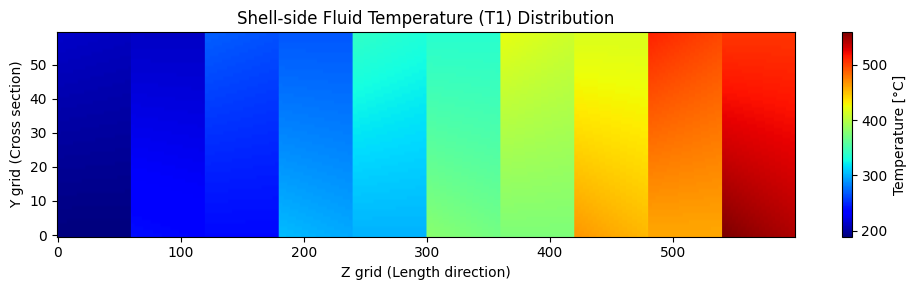

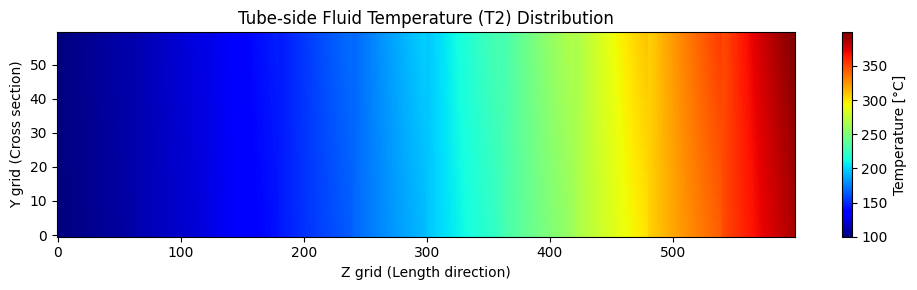

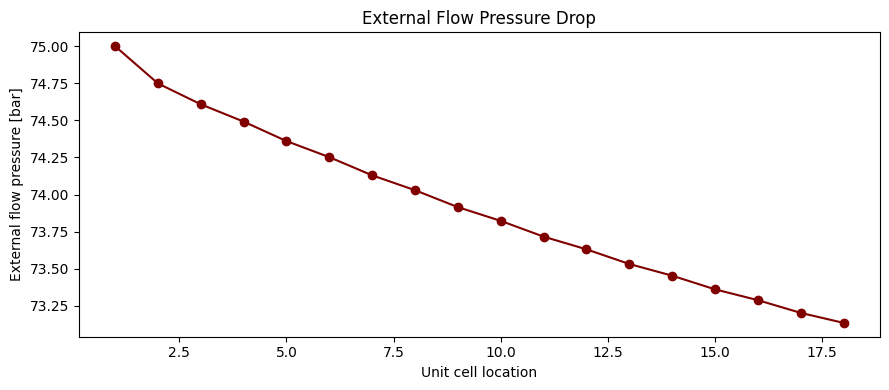

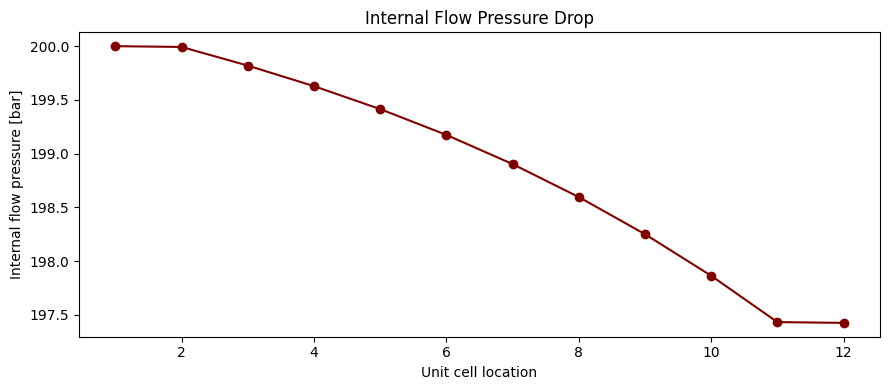

In [34]:
# %% [markdown]
# ### Main function calling the HX function
# این بلاک شامل تابع main است که پارامترهای طراحی در آن تعریف و به تابع HX ارسال می‌شوند.

# %%
def main():
    # پارامترهای هندسی و عملیاتی
    Dt = 0.01905           # Tube outer diameter [m]
    PioDt = 23.81/19.05        # Pitch/diameter of tube in x direction [-]
    PjoDt = 23.81/19.05
    NbL = 8             # برای نوع E، تعداد کل بافل‌ها را اینجا می‌دهیم
    NbR = 1              # اگر NF=0 باشد، NbR باید 1 باشد تا کد درست کار کند
    NF = 0               # 0 برای مبدل نوع E (بدون بافل طولی، تک‌پاسه پوسته)
    Np = 1               # 1 برای تک‌پاسه لوله            # Number of baffles in the right side [-]
    Ntt = 307            # Total number of tubes on one side [-]
    Lk = 6.096             # Length of heat exchanger [m]
    
    ts = 0.0             # Thickness of longitudinal baffle (0 for Type E) [m]
    Bk = 0.4             # Percentage of shell height occupied by tubes [-]
    tk = 0.00952         # Baffle thickness [m]
    BaL = 1.0            # Baffle spacing factor (left) [-]
    BaR = 1.0            # Baffle spacing factor (right) [-]

    
    mdot_h = 45.455        # Hot side mass flow (External) [kg/s]
    mdot_l = 45.455        # Cold side mass flow (Internal) [kg/s]
    Ratio = 1.00         # Heat capacity ratio
    
    T1_in = 550.00       # Hot inlet temperature (External) [°C]
    T2_in = 100.00       # Cold inlet temperature (Internal) [°C]
    P1_in = 7.5e6          # External flow inlet pressure [Pa]
    P2_in = 20e6         # Internal flow inlet pressure [Pa]
    
    FinType = 0          # 0 for bare tubes
    NAF = 10             # Total number of cylindrical pin-fins
    
    DfoDt = 1.0
    Df = DfoDt * Dt
    dfboDt = 0.0
    dfb = dfboDt * Dt
    dft = dfb
    PfoDfb = 4.0
    Pf = PfoDfb * dfb
    
    CtoDt = 0.0
    Ct = CtoDt * Dt
    Ncruc = 4
    
    ExD = 0.0            # Extra space (0 for Type E)
    
    ttoDt = 0.2
    tsoDs = 0.1
    Ht = 0.01
    dsb = 0.0
    dtb = 0.0508 * 0.001
    tsb = 0.00254
    Bypass = 1
    Nss = 0
    
    if Ct < 1e-7:
        Ct = 0.0
        Ncruc = 0
        Ch = 0.0
    if dfb < 1e-7 or DfoDt < 1.0001:
        Pf = 0.0
        dfb = 0.0
        Df = Dt
        
    counter = 1
    CaseRun = 0
    
    print("Running HX Simulation... Please wait.")
    import time
    start_time = time.time()
    
    # فراخوانی تابع اصلی
    Outputs = HX(Dt, PioDt, PjoDt, NbL, NbR, Ntt, Lk, ts, Bk, tk, BaL, BaR, NF, Np, 
                 mdot_h, T2_in, T1_in, Ratio, CaseRun, counter, Df, dfb, dft, Pf, Ct, Ncruc, 
                 ExD, P1_in, P2_in, mdot_l, ttoDt, tsoDs, Ht, dsb, dtb, Nss, tsb, Bypass, FinType, NAF)
    
    print(f"\nExecution time: {time.time() - start_time:.2f} seconds")
    return Outputs

# %% [markdown]
# ### Run the code

# %%
Outputs = main()

# %% [markdown]
# ### Plot temperature and pressure contours
# در این بخش نمودارهای توزیع دما و افت فشار رسم می‌شوند.

# %%
if Outputs != "Violates constraints" and Outputs != "Pressure drop exceeds the input value!":
    T1 = Outputs[0][:, :, 0]  # دمای سیال خارجی (پوسته) برای ستون اول
    T2 = Outputs[1][:, :, 0]  # دمای سیال داخلی (لوله)
    Ts = Outputs[2][:, :, 0]  # دمای جامد
    zgrid = Outputs[5]
    ygrid = Outputs[6]
    Ncolumns = Outputs[7]
    Nrows = Outputs[8]
    Nbaffles = Outputs[9]
    EPin = Outputs[12]
    IPin = Outputs[13]
    DpTB = Outputs[14]
    DpW = Outputs[15]
    DpInt = Outputs[16]
    DpCE = Outputs[17]

    # رسم نمودار دمای سیال در پوسته (T1)
    plt.figure(figsize=(10, 3))
    # چون جریان در بافل‌ها تغییر جهت می‌دهد، برای نمایش صحیح باید ماتریس را در جهت‌های زوج و فرد برگردانیم
    T1_plot = np.copy(T1)
    for i in range(Nbaffles + 2):
        if i % 2 != 0:
            start_col = i * zgrid
            end_col = (i + 1) * zgrid
            T1_plot[:, start_col:end_col] = T1_plot[::-1, start_col:end_col]
            
    plt.imshow(T1_plot, aspect='auto', cmap='jet', origin='lower')
    plt.colorbar(label='Temperature [°C]')
    plt.title('Shell-side Fluid Temperature (T1) Distribution')
    plt.xlabel('Z grid (Length direction)')
    plt.ylabel('Y grid (Cross section)')
    plt.tight_layout()
    plt.show()

    # رسم نمودار دمای سیال در لوله (T2)
    plt.figure(figsize=(10, 3))
    plt.imshow(T2, aspect='auto', cmap='jet', origin='lower')
    plt.colorbar(label='Temperature [°C]')
    plt.title('Tube-side Fluid Temperature (T2) Distribution')
    plt.xlabel('Z grid (Length direction)')
    plt.ylabel('Y grid (Cross section)')
    plt.tight_layout()
    plt.show()

    # رسم نمودار افت فشار جریان خارجی (پوسته)
    PExt = []
    PExt.append(EPin / 1e5)  # تبدیل به bar
    for i in range(Nbaffles + 1):
        PExt.append(PExt[-1] - DpTB[Nbaffles + 1 - i] / 1e5)
        if i < Nbaffles:
            PExt.append(PExt[-1] - DpW[Nbaffles - i] / 1e5)
    
    LocExt = range(1, len(PExt) + 1)
    plt.figure(figsize=(9, 4))
    plt.plot(LocExt, PExt, marker='o', color='maroon', linestyle='-')
    plt.title('External Flow Pressure Drop')
    plt.xlabel('Unit cell location')
    plt.ylabel('External flow pressure [bar]')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # رسم نمودار افت فشار جریان داخلی (لوله)
    PInt = []
    PInt.append(IPin / 1e5)
    PInt.append(PInt[-1] - DpCE / 2e5)
    for i in range(Nbaffles + 1):
        PInt.append(PInt[-1] - DpInt[i] / 1e5)
    PInt.append(PInt[-1] - DpCE / 2e5)
    
    LocInt = range(1, len(PInt) + 1)
    plt.figure(figsize=(9, 4))
    plt.plot(LocInt, PInt, marker='o', color='maroon', linestyle='-')
    plt.title('Internal Flow Pressure Drop')
    plt.xlabel('Unit cell location')
    plt.ylabel('Internal flow pressure [bar]')
    plt.grid(False)
    plt.tight_layout()
    plt.show()
else:
    print("Simulation failed with message:", Outputs)